# 07 - Near-Duplicate Detection: Coordinated Filing Patterns

Notebooks 05 and 06 found community structure, and along the way, a population split: template filers (legal citation language, credit repair playbooks) vs narrative filers (people describing their own situation).

This notebook asks a different question. Forget communities for a moment. Within the whole sample, are there complaints that are suspiciously similar to each other -- similar enough, and close enough together in time, that independent filing seems unlikely?

That's the core fraud signal we're after: not "is this complaint fake" but "do these complaints share a common cause rather than being independent."

Worth saying directly: this technique isn't fraud-specific. The same logic -- high textual similarity plus close temporal proximity, used to infer a shared underlying cause -- applies anywhere you're trying to figure out whether multiple independent-looking records actually describe the same event. Missing persons casework is the clearest example: two case narratives that are unusually similar, reported within a short window of each other, may describe people who disappeared in the same incident. The mechanics are the same; only the third disambiguating signal changes -- here it's Company, there it might be location or last-known-whereabouts.

We run this on the full sample, not just template filers. Worth testing rather than assuming that narrative filers can't show coordinated patterns too.


## Setup

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter
import itertools

sns.set_theme(style="whitegrid")

from src.embeddings import load_model, generate_embeddings


## Load data

Using the full sample from notebook 06 (post empty-narrative filtering), not just the narrative subset. We want to test both populations for coordinated patterns, not assume only one can show them.


In [2]:
SAMPLE_SIZE = 15000

df = pd.read_parquet("../data/processed/complaints_50k.parquet")

df_sample = df.iloc[:SAMPLE_SIZE].copy()
df_sample = df_sample[df_sample["Consumer complaint narrative"].notna()].copy()
df_sample = df_sample[df_sample["Consumer complaint narrative"].str.strip() != ""].copy()
df_sample = df_sample.reset_index(drop=True)

texts = df_sample["Consumer complaint narrative"].astype(str).tolist()

df_sample["Date received"] = pd.to_datetime(df_sample["Date received"])

print(f"Complaints loaded: {len(df_sample):,}")
print(f"Date range: {df_sample['Date received'].min().date()} to {df_sample['Date received'].max().date()}")


Complaints loaded: 6,150
Date range: 2019-01-02 to 2022-12-31


## Generate embeddings

Same model, fresh run on this sample.

In [3]:
model = load_model()
embeddings = generate_embeddings(texts, model)

print(f"Embeddings: {embeddings.shape}")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/193 [00:00<?, ?it/s]

Embeddings: (6150, 384)


## Find each complaint's single nearest neighbour

For near-duplicate detection we don't need a kNN graph (k=10) -- we need, for every complaint, just its single closest match and that similarity score. This is a different question than community detection: we're not asking "what's the neighbourhood," we're asking "is there one specific complaint suspiciously close to this one."

For 15k complaints, the full pairwise similarity matrix is about 1.8GB in float32 (15000 squared times 4 bytes) -- large but workable. If this is too slow or memory-heavy on your machine, we can chunk it; flagging that here so it's not a silent assumption. Lucky for me we are running on a third of the 15k because many rows are empty.


In [4]:
# Full pairwise cosine similarity matrix
sim_matrix = cosine_similarity(embeddings)

# Zero out the diagonal so a complaint's "nearest neighbour" isn't itself
np.fill_diagonal(sim_matrix, -1)

# For each complaint, find its single most similar other complaint
nearest_idx = sim_matrix.argmax(axis=1)
nearest_sim = sim_matrix.max(axis=1)

df_sample["nearest_match_idx"] = nearest_idx
df_sample["nearest_match_sim"] = nearest_sim

print(f"Nearest-match similarity -- mean: {nearest_sim.mean():.3f}, median: {np.median(nearest_sim):.3f}")
print(f"Max: {nearest_sim.max():.3f}, min: {nearest_sim.min():.3f}")


Nearest-match similarity -- mean: 0.781, median: 0.757
Max: 1.000, min: 0.230


## Look at the distribution before picking a threshold

We picked 0.85 as a starting point, but let's actually look at the shape of this distribution before committing. If there's a natural break -- a gap, a long tail, a bimodal shape -- that tells us more than an arbitrary number would.


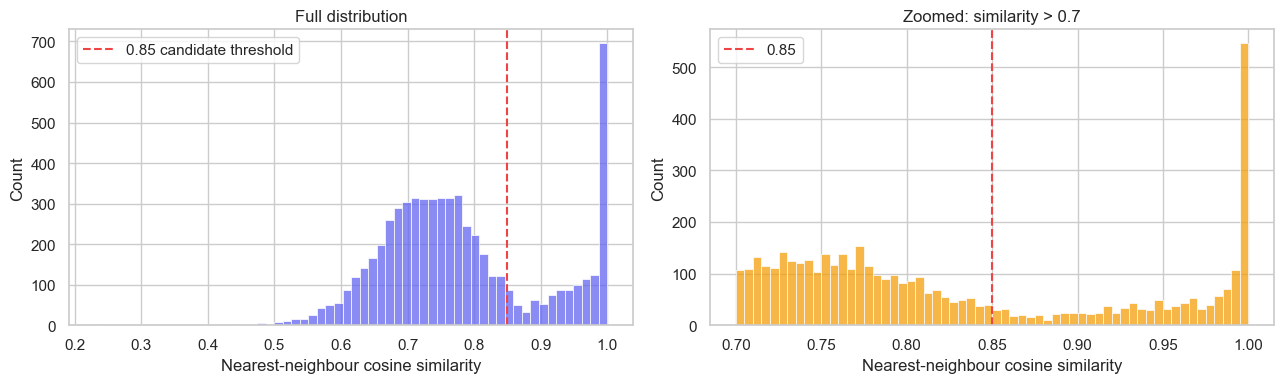

  >= 0.8: 2,126 complaints (34.6%)
  >= 0.85: 1,537 complaints (25.0%)
  >= 0.9: 1,327 complaints (21.6%)
  >= 0.93: 1,165 complaints (18.9%)
  >= 0.95: 1,013 complaints (16.5%)
  >= 0.97: 849 complaints (13.8%)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(nearest_sim, bins=60, ax=axes[0], color="#6366f1")
axes[0].axvline(0.85, color="#ef4444", linestyle="--", label="0.85 candidate threshold")
axes[0].set_xlabel("Nearest-neighbour cosine similarity")
axes[0].set_title("Full distribution")
axes[0].legend()

sns.histplot(nearest_sim[nearest_sim > 0.7], bins=60, ax=axes[1], color="#f59e0b")
axes[1].axvline(0.85, color="#ef4444", linestyle="--", label="0.85")
axes[1].set_xlabel("Nearest-neighbour cosine similarity")
axes[1].set_title("Zoomed: similarity > 0.7")
axes[1].legend()

plt.tight_layout()
plt.show()

for t in [0.80, 0.85, 0.90, 0.93, 0.95, 0.97]:
    n = (nearest_sim >= t).sum()
    print(f"  >= {t}: {n:,} complaints ({n/len(df_sample)*100:.1f}%)")


In [6]:
exact_or_near = df_sample[df_sample["nearest_match_sim"] >= 0.999]
print(f"Count: {len(exact_or_near)}")
for i, row in exact_or_near.head(5).iterrows():
    match_text = texts[row["nearest_match_idx"]]
    print(f"\nComplaint {i}: {row['Consumer complaint narrative'][:200]}")
    print(f"Match     : {match_text[:200]}")
    print(f"Same text?: {row['Consumer complaint narrative'] == match_text}")

Count: 405

Complaint 1: I am a victim of identity theft. The information listed below, which appears on my credit report, does not relate to any transaction ( s ) that I have made. It is the result of identity theft.
Match     : I am a victim of identity theft. The information listed below, which appears on my credit report, does not relate to any transaction ( s ) that I have made. It is the result of identity theft.
Same text?: True

Complaint 9: In accordance with the fair credit Reporting act XXXX Account # XXXX, has violated my rights. 

15 USC 1681 Section 602 States I have the right to privacy.

15 USC 1681 Section 604 A Section 2 : It al
Match     : In accordance with the Fair Credit Reporting Act XXXX Account # XXXX, has violated my rights. 

15 USC 1681 Section 602 States I have the right to privacy.

15 USC 1681 Section 604 A Section 2 : It al
Same text?: False

Complaint 40: I found inaccurate and incorrect data on my credit report and this wrong information should not be 

In [7]:
THRESHOLD = 0.85  # I choose this since the graph above shows a clear drop-off in the number of complaints above this threshold. It seems like a reasonable cutoff for "near-duplicate" complaints.

df_sample["is_near_duplicate"] = df_sample["nearest_match_sim"] >= THRESHOLD

n_flagged = df_sample["is_near_duplicate"].sum()
print(f"Flagged at threshold {THRESHOLD}: {n_flagged:,} complaints ({n_flagged/len(df_sample)*100:.1f}%)")


Flagged at threshold 0.85: 1,537 complaints (25.0%)


## Group flagged complaints into duplicate clusters

A pair is one thing, but real campaigns usually involve more than two near-identical complaints. We need to group flagged complaints into connected clusters -- if A is near-duplicate of B, and B is near-duplicate of C, all three belong to one cluster, even if A and C weren't each other's single nearest neighbour.

Simple approach: build a graph from the near-duplicate edges (threshold-based, not kNN) and take connected components.


In [8]:
import networkx as nx

G_dup = nx.Graph()
G_dup.add_nodes_from(df_sample.index)

# Add an edge between every pair where similarity crosses the threshold,
# not just nearest-neighbour pairs -- a complaint might have multiple
# near-duplicates, not only its single closest match.
rows, cols = np.where(sim_matrix >= THRESHOLD)
for r, c in zip(rows, cols):
    if r < c:  # avoid adding both directions and self-loops
        G_dup.add_edge(r, c, weight=sim_matrix[r, c])

components = [c for c in nx.connected_components(G_dup) if len(c) > 1]
components = sorted(components, key=len, reverse=True)

print(f"Duplicate clusters found (size > 1): {len(components)}")
print(f"Cluster sizes: {[len(c) for c in components[:20]]}")
print(f"Total complaints involved: {sum(len(c) for c in components):,}")


Duplicate clusters found (size > 1): 218
Cluster sizes: [353, 82, 66, 61, 36, 33, 28, 23, 22, 21, 20, 17, 16, 16, 14, 13, 12, 11, 10, 10]
Total complaints involved: 1,537


c:\Users\pablo\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


NameError: name 'all_dup_indices' is not defined

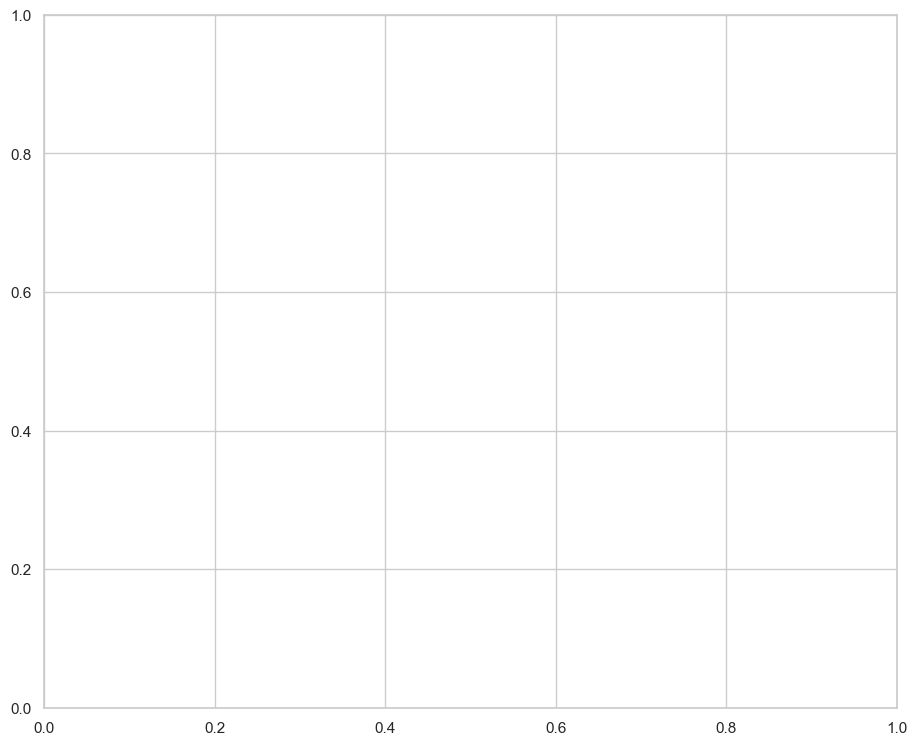

In [ ]:
## Visualize duplicate clusters on the UMAP projection

import umap.umap_ as umap

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

embedding_2d = reducer.fit_transform(embeddings)



Total complaints in some duplicate cluster: 1,537


c:\Users\pablo\anaconda3\Lib\site-packages\networkx\drawing\nx_pylab.py:457: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  node_collection = ax.scatter(


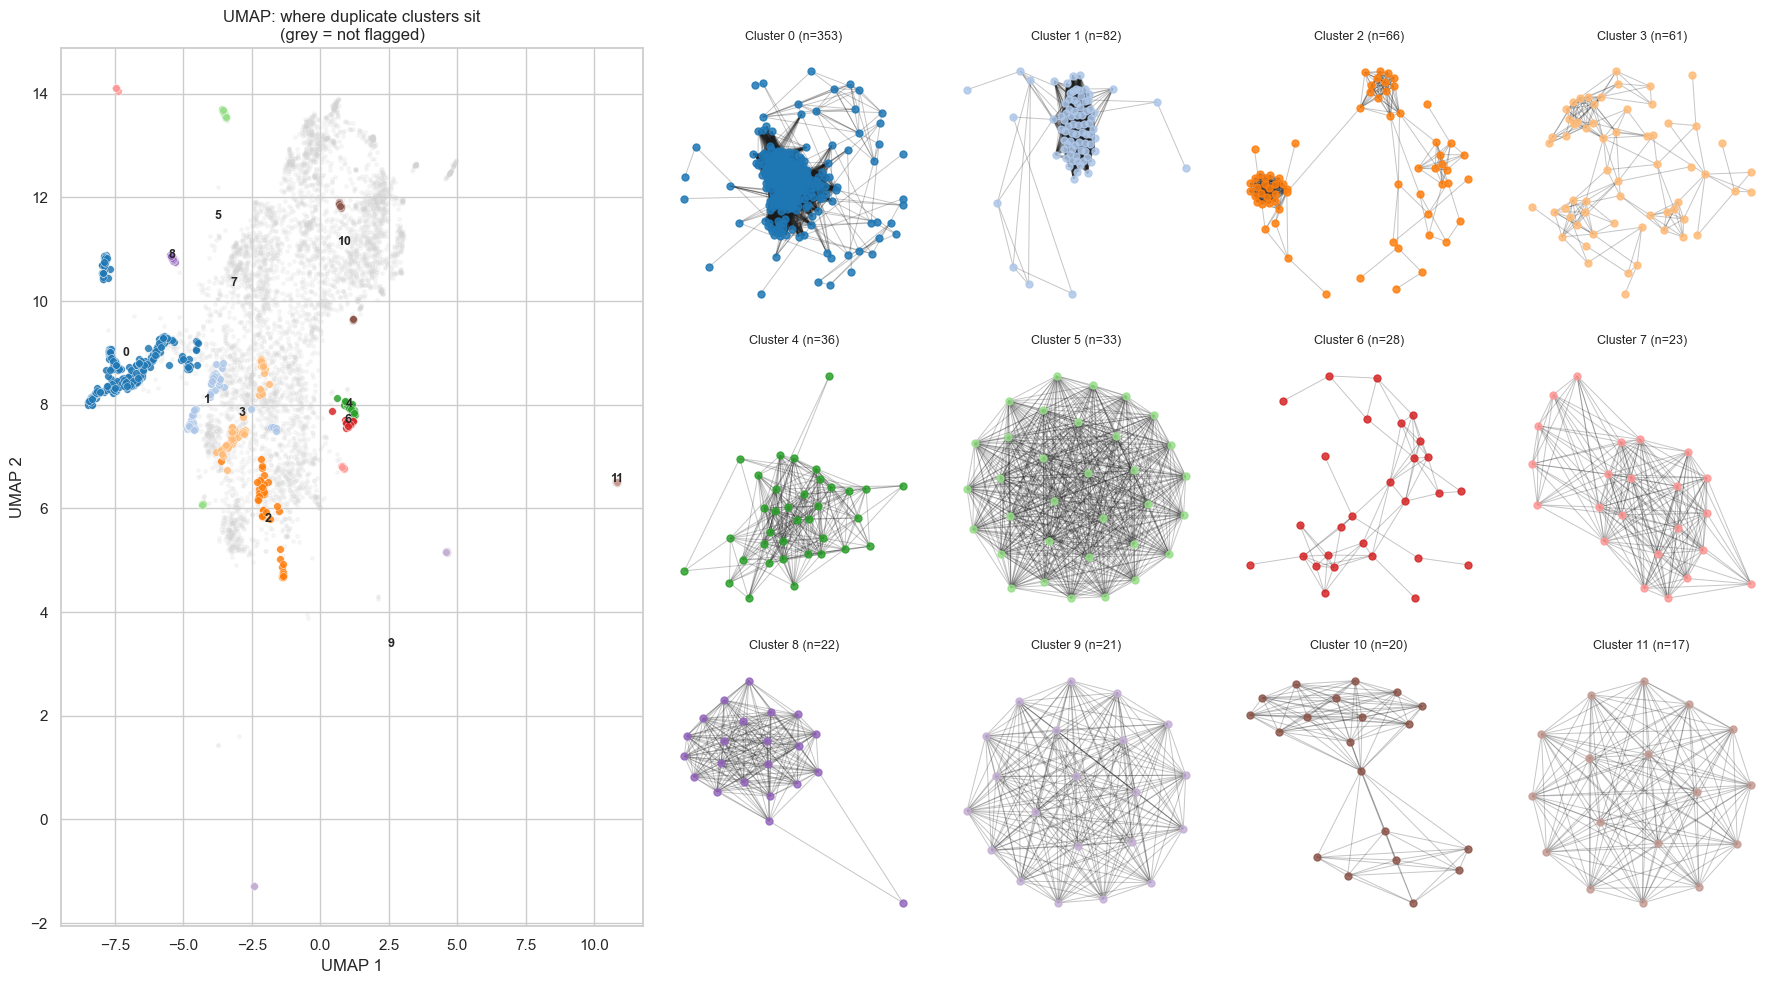

In [12]:
all_dup_indices = set()
for c in components:
    all_dup_indices.update(c)

print(f"Total complaints in some duplicate cluster: {len(all_dup_indices):,}")
## Combined view: UMAP context + network structure

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(3, 5, width_ratios=[2.2, 1, 1, 1, 1])

# --- Left: UMAP overview, large panel ---
ax_umap = fig.add_subplot(gs[:, 0])

not_dup_mask = ~df_sample.index.isin(all_dup_indices)
ax_umap.scatter(
    embedding_2d[not_dup_mask, 0], embedding_2d[not_dup_mask, 1],
    s=6, alpha=0.15, color="lightgrey"
)

N_CLUSTERS_TO_SHOW = 12
palette = sns.color_palette("tab20", n_colors=N_CLUSTERS_TO_SHOW)

for i, cluster in enumerate(components[:N_CLUSTERS_TO_SHOW]):
    idx = list(cluster)
    ax_umap.scatter(
        embedding_2d[idx, 0], embedding_2d[idx, 1],
        s=30, alpha=0.85, color=palette[i],
        edgecolors="white", linewidths=0.3
    )
    cx, cy = embedding_2d[idx, 0].mean(), embedding_2d[idx, 1].mean()
    ax_umap.annotate(str(i), (cx, cy), fontsize=9, fontweight="bold", ha="center")

ax_umap.set_title("UMAP: where duplicate clusters sit\n(grey = not flagged)")
ax_umap.set_xlabel("UMAP 1")
ax_umap.set_ylabel("UMAP 2")

# --- Right: network structure for top clusters, small panels ---
positions = [(r, c) for r in range(3) for c in range(1, 5)]

for i, (r, c) in enumerate(positions[:N_CLUSTERS_TO_SHOW]):
    ax_net = fig.add_subplot(gs[r, c])
    cluster = components[i]
    subG = G_dup.subgraph(cluster)
    pos = nx.spring_layout(subG, seed=42, k=0.5)

    nx.draw_networkx_nodes(subG, pos, ax=ax_net, node_size=25, node_color=palette[i], alpha=0.85)
    nx.draw_networkx_edges(subG, pos, ax=ax_net, alpha=0.25, width=0.7)

    ax_net.set_title(f"Cluster {i} (n={len(cluster)})", fontsize=9)
    ax_net.axis("off")

plt.tight_layout()
plt.show()


## Profile the biggest clusters

For each cluster, three things matter for interpretation:

1. Time spread -- are these complaints bunched in a tight window, or spread over years? Tight windows are the actual fraud/coordination signal.
2. Company diversity -- many different companies targeted with the same near-identical text suggests a template/campaign. One company dominant suggests a real shared issue at that company (possibly still worth investigating, but a different kind of finding).
3. What the text actually says -- read a couple of examples.


In [13]:
def profile_cluster(cluster_indices, df, top_n_text=2):
    idx = list(cluster_indices)
    sub = df.loc[idx]

    date_range = sub["Date received"].max() - sub["Date received"].min()
    company_counts = sub["Company"].value_counts()
    top_company_pct = company_counts.iloc[0] / len(sub) * 100 if len(company_counts) else 0

    return {
        "size": len(idx),
        "date_min": sub["Date received"].min().date(),
        "date_max": sub["Date received"].max().date(),
        "date_spread_days": date_range.days,
        "n_unique_companies": sub["Company"].nunique(),
        "top_company": company_counts.index[0] if len(company_counts) else None,
        "top_company_pct": round(top_company_pct, 1),
        "sample_text": sub["Consumer complaint narrative"].iloc[0][:300]
    }


cluster_profiles = []
for cluster in components[:20]:
    profile = profile_cluster(cluster, df_sample)
    cluster_profiles.append(profile)

profile_df = pd.DataFrame(cluster_profiles)
profile_df.index.name = "cluster_rank"
profile_df[["size", "date_spread_days", "n_unique_companies", "top_company", "top_company_pct"]]


,size,date_spread_days,n_unique_companies,top_company,top_company_pct
cluster_rank,,,,,
0,353,449,23,Experian Information Solutions Inc.,33.1
1,82,870,3,"EQUIFAX, INC.",56.1
2,66,762,5,"EQUIFAX, INC.",34.8
3,61,456,3,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",39.3
4,36,207,3,"EQUIFAX, INC.",36.1
5,33,272,3,"EQUIFAX, INC.",42.4
6,28,212,4,"EQUIFAX, INC.",39.3
7,23,345,3,"EQUIFAX, INC.",43.5
8,22,949,17,CAPITAL ONE FINANCIAL CORPORATION,13.6


## Read this table carefully -- it's the actual finding

A few patterns to look for:

Tight date spread plus low company diversity -> likely a real, single shared event at one company (a data breach, a policy change, a system bug). Worth flagging to that company specifically, not necessarily fraud.

Tight date spread plus high company diversity -> the strongest coordination signal. The same template hitting many different companies in a short window looks like a filing campaign, not independent consumer experiences.

Wide date spread, regardless of company diversity -> less interesting. This just means the same complaint template has been reused over a long period -- common for popular legal templates (we already know these exist from notebooks 05/06), not necessarily coordinated filing, just a popular script being reused independently over time.


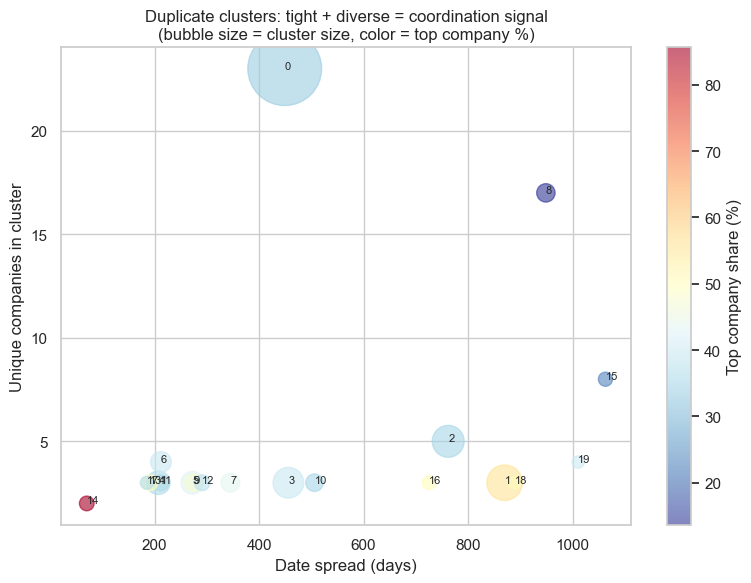

Bottom-left, red bubbles = tightest, most company-diverse, most concentrated = look here first


In [14]:
fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(
    profile_df["date_spread_days"],
    profile_df["n_unique_companies"],
    s=profile_df["size"] * 8,
    alpha=0.6,
    c=profile_df["top_company_pct"],
    cmap="RdYlBu_r"
)

for i, row in profile_df.iterrows():
    ax.annotate(str(i), (row["date_spread_days"], row["n_unique_companies"]), fontsize=8)

ax.set_xlabel("Date spread (days)")
ax.set_ylabel("Unique companies in cluster")
ax.set_title("Duplicate clusters: tight + diverse = coordination signal\n(bubble size = cluster size, color = top company %)")
plt.colorbar(scatter, ax=ax, label="Top company share (%)")
plt.tight_layout()
plt.show()

print("Bottom-left, red bubbles = tightest, most company-diverse, most concentrated = look here first")


## Read the most suspicious cluster in full

Pick whichever cluster from the plot above looks most coordination-like (tight date spread, multiple companies) and actually read several of its complaints side by side. This is the step that turns a statistical signal into something you'd trust enough to flag.


In [15]:
CLUSTER_TO_INSPECT = 8

cluster_idx = list(components[CLUSTER_TO_INSPECT])
sub = df_sample.loc[cluster_idx].sort_values("Date received")

print(f"Cluster {CLUSTER_TO_INSPECT}: {len(sub)} complaints")
print(f"Date range: {sub['Date received'].min().date()} to {sub['Date received'].max().date()}")
print(f"Companies: {sub['Company'].value_counts().to_dict()}")
print()

for _, row in sub.head(5).iterrows():
    print(f"[{row['Date received'].date()}] {row['Company']}")
    print(row["Consumer complaint narrative"][:300])
    print("-" * 70)


Cluster 8: 22 complaints
Date range: 2020-03-27 to 2022-11-01
Companies: {'CAPITAL ONE FINANCIAL CORPORATION': 3, 'TRANSUNION INTERMEDIATE HOLDINGS, INC.': 3, 'Resurgent Capital Services L.P.': 2, 'Experian Information Solutions Inc.': 1, 'Portfolio Recovery Associates, LLC': 1, 'CLGF Holdco 1, LLC': 1, 'REGIONS FINANCIAL CORPORATION': 1, 'JPMORGAN CHASE & CO.': 1, 'American First Finance, Inc.': 1, 'Bread Financial Holdings, Inc.': 1, 'ACIMA CREDIT, LLC': 1, 'CITIBANK, N.A.': 1, 'SYNCHRONY FINANCIAL': 1, 'EQUIFAX, INC.': 1, 'I.C. System, Inc.': 1, 'ERC': 1, 'BANK OF AMERICA, NATIONAL ASSOCIATION': 1}

[2020-03-27] Experian Information Solutions Inc.
I filed a dispute in regards to the incorrect information on my credit report and its been well over 30 days.
----------------------------------------------------------------------
[2020-03-28] TRANSUNION INTERMEDIATE HOLDINGS, INC.
I filed a dispute in regards to the incorrect items on my credit report and its been well over 30 days. I ha

## Cross-check against the template/narrative split

One more useful cut: do these duplicate clusters skew toward template filers, narrative filers, or both? If you saved community_descriptions and the narrative/template split from notebook 06, this is worth checking.

If it's purely template filers, that supports the credit-repair-mill story cleanly. If narrative filers also show up in tight duplicate clusters, that's a genuinely interesting and slightly more concerning finding -- it would mean real personal accounts are also showing up as near-duplicates, which could indicate something like astroturfing, coached complaints, or a shared real incident.


In [ ]:
all_dup_indices = set()
for c in components:
    all_dup_indices.update(c)

df_sample["in_duplicate_cluster"] = df_sample.index.isin(all_dup_indices)

print(f"Total complaints in some duplicate cluster: {df_sample['in_duplicate_cluster'].sum():,}")
print(f"As % of sample: {df_sample['in_duplicate_cluster'].mean()*100:.1f}%")

try:
    df_narrative_labels = pd.read_parquet("../data/processed/narrative_complaints.parquet")
    narrative_text_set = set(df_narrative_labels["Consumer complaint narrative"].tolist())
    df_sample["filer_type_guess"] = df_sample["Consumer complaint narrative"].apply(
        lambda t: "narrative" if t in narrative_text_set else "template_or_unknown"
    )
    print()
    print(df_sample.groupby("filer_type_guess")["in_duplicate_cluster"].mean().to_string())
except FileNotFoundError:
    print("\nnarrative_complaints.parquet not found -- skipping template/narrative cross-check")


In [18]:
## Narrative-only near-duplicate check

import pickle

df_narr = pd.read_parquet("../data/processed/narrative_complaints.parquet")
with open("../data/processed/narrative_embeddings.pkl", "rb") as f:
    narrative_embeddings_check = pickle.load(f)

df_narr["Date received"] = pd.to_datetime(df_narr["Date received"])

sim_matrix_narr = cosine_similarity(narrative_embeddings_check)
np.fill_diagonal(sim_matrix_narr, -1)
nearest_sim_narr = sim_matrix_narr.max(axis=1)

print(f"Narrative filers: {len(df_narr):,}")
print(f"Nearest-match similarity -- mean: {nearest_sim_narr.mean():.3f}, median: {np.median(nearest_sim_narr):.3f}")
for t in [0.80, 0.85, 0.90, 0.95, 0.99]:
    n = (nearest_sim_narr >= t).sum()
    print(f"  >= {t}: {n:,} ({n/len(df_narr)*100:.1f}%)")

THRESHOLD_NARR = 0.85
G_dup_narr = nx.Graph()
G_dup_narr.add_nodes_from(df_narr.index)

rows, cols = np.where(sim_matrix_narr >= THRESHOLD_NARR)
for r, c in zip(rows, cols):
    if r < c:
        G_dup_narr.add_edge(r, c, weight=sim_matrix_narr[r, c])

components_narr = [c for c in nx.connected_components(G_dup_narr) if len(c) > 1]
components_narr = sorted(components_narr, key=len, reverse=True)

print(f"\nDuplicate clusters in narrative filers (size > 1): {len(components_narr)}")
print(f"Sizes: {[len(c) for c in components_narr[:20]]}")
print(f"Total complaints involved: {sum(len(c) for c in components_narr):,}")

Narrative filers: 2,515
Nearest-match similarity -- mean: 0.719, median: 0.707
  >= 0.8: 345 (13.7%)
  >= 0.85: 197 (7.8%)
  >= 0.9: 171 (6.8%)
  >= 0.95: 147 (5.8%)
  >= 0.99: 130 (5.2%)

Duplicate clusters in narrative filers (size > 1): 43
Sizes: [33, 23, 21, 10, 6, 6, 6, 5, 5, 4, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3]
Total complaints involved: 197


In [19]:
cluster_idx = list(components_narr[0])
sub = df_narr.loc[cluster_idx].sort_values("Date received")

print(f"Cluster size: {len(sub)}")
print(f"Date range: {sub['Date received'].min().date()} to {sub['Date received'].max().date()}")
print(f"Companies: {sub['Company'].value_counts().to_dict()}")
print()
for _, row in sub.head(5).iterrows():
    print(f"[{row['Date received'].date()}] {row['Company']}")
    print(row["Consumer complaint narrative"][:300])
    print("-" * 70)

Cluster size: 33
Date range: 2022-03-18 to 2022-12-15
Companies: {'EQUIFAX, INC.': 14, 'Experian Information Solutions Inc.': 10, 'TRANSUNION INTERMEDIATE HOLDINGS, INC.': 9}

[2022-03-18] EQUIFAX, INC.
Hi I am submitting this XXXX XXXX XXXX this isn't any influence and this is not a third party. XXXX has low and unfair credit number for me in their report. I have complained. The problem has not been resolved. my fico has me at a credit score over XXXX has me at a score around XXXX. That is a huge 
----------------------------------------------------------------------
[2022-04-26] EQUIFAX, INC.
Hi I am submitting this XXXX XXXX XXXX this isn't any influence and this is not a third party. XXXX has low and unfair credit number for me in their report. I have complained. The problem has not been resolved. my fico has me at a credit score over 719XXXX has me at a score around 590. That is a hug
----------------------------------------------------------------------
[2022-05-20] EQUIFAX, INC.

## What did we find?

Ran this on the full 15k sample (well, 6,150 after dropping empty narratives)
and on the narrative-only subset separately.

**Full sample**: 1,537 complaints flagged at threshold 0.85 (25%), grouping
into 218 clusters. No tight time windows anywhere -- every cluster spreads
over months to years (449 days for the biggest one, up to 1,063 days for
some smaller ones). Read several clusters directly: this is template reuse,
not coordination. People independently finding the same FCRA dispute script
online and using it whenever they happen to have a credit reporting issue.
Company concentration is mostly explained by the fact that these templates
are written for bureau disputes, so of course Equifax/Experian/TransUnion
dominate -- there are only three bureaus.

**Narrative-only subset** (2,515 complaints, template filers already
removed): near-duplicate rate drops to 7.8%, about a third of the full
sample's rate. Makes sense -- genuine personal narratives should be more
diverse than copy-pasted scripts. 43 clusters, much smaller than the full
sample's (largest is 33 vs 353).

Read the biggest narrative cluster (n=33) expecting something genuinely
interesting -- and found a casual-toned script instead. "This isn't any
influence and this is not a third party... fico has me at a credit score
over 719, [bureau] has me at a score around 590" repeated near-verbatim
across 33 complaints, March to December 2022, company name swapped each
time. This was classified as narrative in notebook 06 because it doesn't
cite statutes and reads informally -- but it's still a script. Good lesson:
tone isn't the same as originality. A template can sound casual.

So the honest takeaway: near-duplicate clustering in this dataset is almost
entirely a template-reuse phenomenon, even after trying to filter templates
out. No coordinated, tight-window campaigns found in either population --
worth flagging that the sample size (a few thousand rows out of what's
presumably millions in the full CFPB dataset) means this is a limited test,
not proof that no coordination exists in the full data. A real campaign
could easily be invisible in a small arbitrary slice like this one.

Brute-forcing this at full dataset scale isn't feasible (pairwise similarity
is quadratic, this already took real memory at 15k). Next step is FAISS or
ChromaDB for approximate similarity search -- which is also exactly the
infrastructure the investigator query tool needs, so it's not a detour,
it's the same piece of work serving two purposes.